# Geometric & Intensity Transformations


Apply classical image processing operations using Python and the `(PIL)` library. Complete both tasks and save your output images for comparison.


In [113]:
# Import the library
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.cm as cm

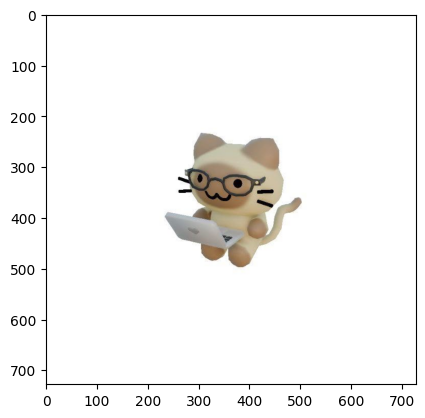

In [114]:
# ── Load image ────────────────────────────────────
img = Image.open("labtop.jpeg")
plt.imshow(img)

### 1. Scale (increase size)
Double the image dimensions using `Image.resize()` with high-quality resampling `(LANCZOS)`.

In [115]:
# Get the size of the image
width, height = img.size
# scaling factors
x=2
y=2

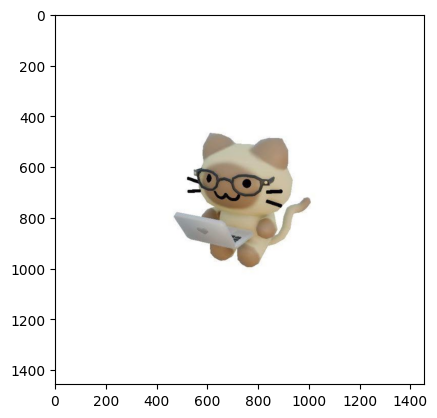

In [116]:
# ── 1. Increase size (scale ×2) ────────────────────
new_width = width * x
new_height = height * y
# Resize the image using PIL's built-in method
scaled_img = img.resize((new_width, new_height), Image.LANCZOS)
plt.imshow(scaled_img)

In [117]:
# Save the scaled image and print the sizes (The new image name should be "task1_1_scaled.jpg")
scaled_img.save("task1_1_scaled.jpg")
print(f"Original size: {img.size}")
print(f"Scaled size: {scaled_img.size}")

Original size: (728, 728)
Scaled size: (1456, 1456)


 non-uniform scale (cx=2, cy=1) → stretch horizontally only

In [118]:
cx=2
cy=1
width,height = img.size
new_width= width*cx
new_height= height*cy

In [119]:
streched_img = img.resize((new_width, new_height), Image.LANCZOS)

Original size: (728, 728)
Scaled size: (1456, 728)


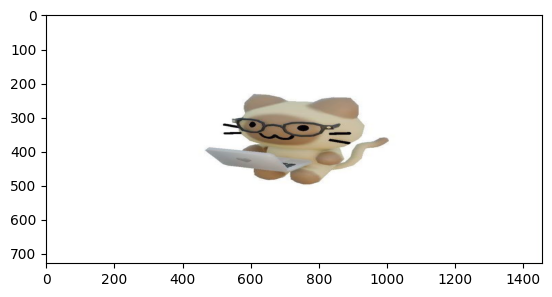

In [120]:

print(f"Original size: {img.size}")
print(f"Scaled size: {streched_img.size}")
plt.imshow(streched_img)

### 2. Rotate 120°
Rotate the image by 120 degrees, expanding the canvas to fit the full rotated image.

(996, 996)


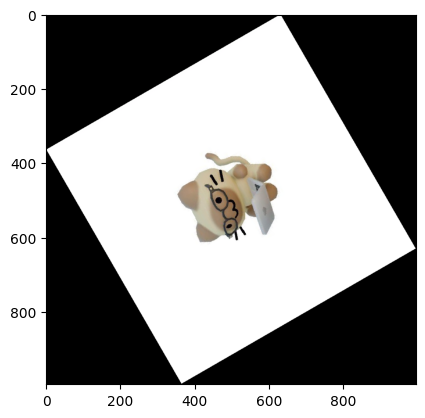

In [121]:
# ── 2. Rotate 120 degrees ──────────────────────────
# Save the scaled image and print the sizes (The new image name should be "task1_2_rotated.jpg")
rotated_img = img.rotate(120, expand=True)
rotated_img.save("task1_2_rotated.jpg")
print(rotated_img.size)
plt.imshow(rotated_img)

### 3. Shear

In [122]:
img.size

(728, 728)

In [123]:
# -- d. define the shear matrix ──────────────────────────
# Choose X-axis or Y-axis shear. The shear factor controls how much the image slants — start with 0.5 then experiment.
shx=0.5
shy=0.
tx=5
ty=0

In [124]:
# -- e. Apply the shear transformation to the image ──────────────────────────
# PIL's transform() takes the inverse affine matrix:
# [ 1    shx   tx ]
# [ shy  1     ty ]
matrix=(1,shx,tx,shy,1,ty)
width, height = img.size
sheared_img = img.transform(
    (width, height),
    Image.AFFINE,
    matrix,
    resample=Image.Resampling.BICUBIC
)

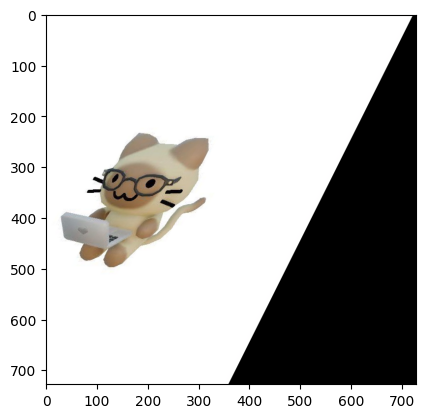

In [125]:
# -- f. Save the sheared image(The new image name should be "task1_3_sheared.jpg")
sheared_img.save("task1_3_sheared.jpg")
plt.imshow(sheared_img)

### Experiment and compare
Try these:

— Change shear factor from 0.5 to 0.1, 0.3, 0.8 and compare results

— Switch from X-axis to Y-axis shear matrix

— Update the canvas multiplier to match your new factor

— Try combining X and Y shear in one matrix

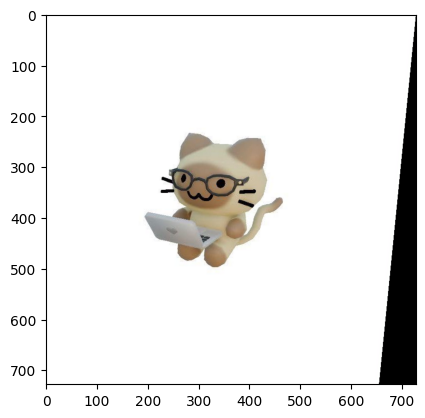

In [126]:
shx = 0.1
matrix = (1, shx, 0, 0, 1, 0)
width, height = img.size

sheared_img = img.transform((width, height), Image.AFFINE, matrix, resample=Image.Resampling.BICUBIC)

plt.imshow(sheared_img)

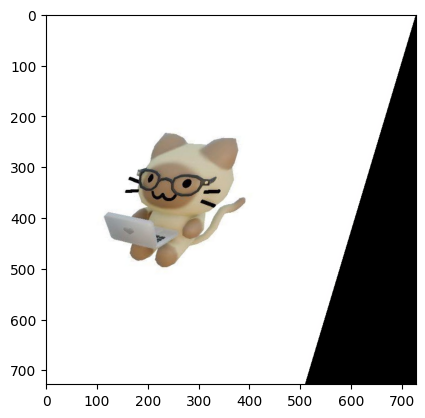

In [127]:
shx = 0.3
matrix = (1, shx, 0, 0, 1, 0)
width, height = img.size

sheared_img = img.transform((width, height), Image.AFFINE, matrix, resample=Image.Resampling.BICUBIC)

plt.imshow(sheared_img)

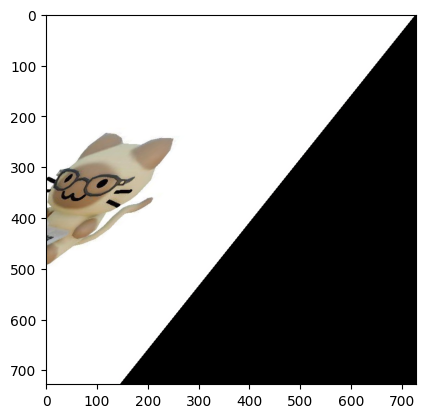

In [128]:
shx = 0.8
matrix = (1, shx, 0, 0, 1, 0)
width, height = img.size

sheared_img = img.transform((width, height), Image.AFFINE, matrix, resample=Image.Resampling.BICUBIC)

plt.imshow(sheared_img)

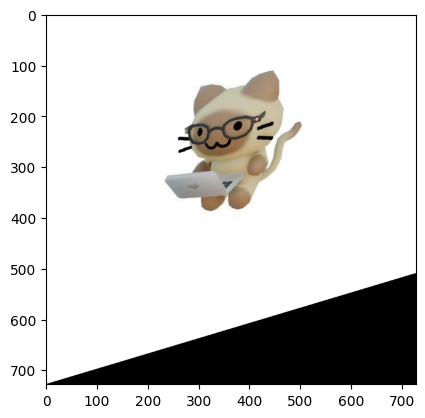

In [129]:
shy = 0.3
matrix = (1, 0, 0, shy, 1, 0)
width, height = img.size

y_sheared = img.transform((width, height), Image.AFFINE, matrix, resample=Image.Resampling.BICUBIC)

plt.imshow(y_sheared)

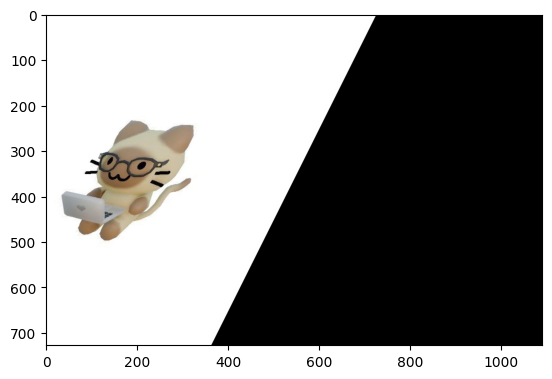

In [130]:
shx = 0.5
matrix = (1, shx, 0, 0, 1, 0)
width, height = img.size

new_width = width + int(height * abs(shx))
expanded_img = img.transform((new_width, height), Image.AFFINE, matrix, resample=Image.Resampling.BICUBIC)

plt.imshow(expanded_img)

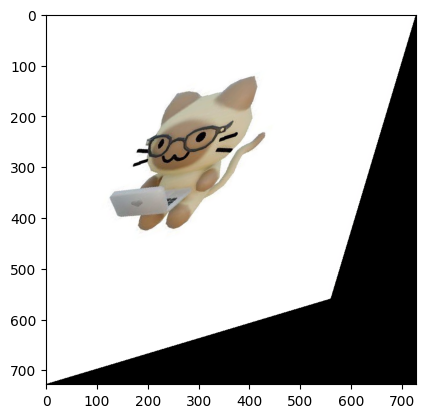

In [131]:
shx = 0.3
shy = 0.3
matrix = (1, shx, 0, shy, 1, 0)
width, height = img.size

combined_img = img.transform((width, height), Image.AFFINE, matrix, resample=Image.Resampling.BICUBIC)

plt.imshow(combined_img)

# Intensity Transformations
Negative · Log · Power Law (Gamma)

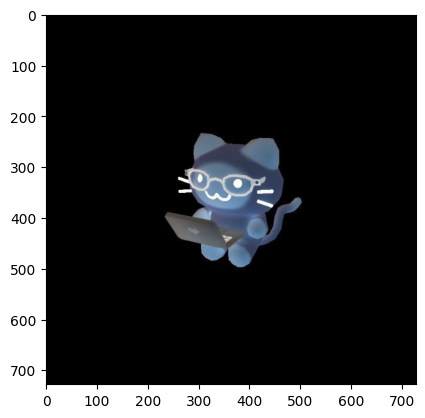

In [132]:

# ── 1. Negative ────────────────────────────────────
# Method 1: NumPy array manipulation
import numpy as np
arr = np.array(img)
negative_img = 255 - arr
negative_img = Image.fromarray(negative_img)
negative_img.save("task2_1_negative.jpg")
plt.imshow(negative_img)

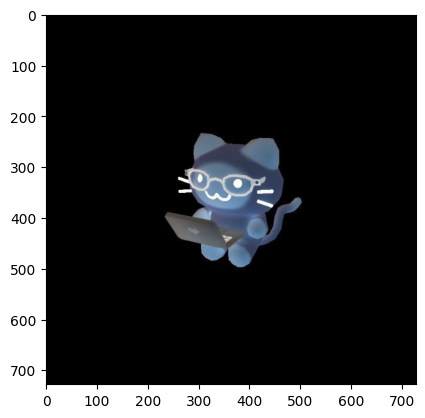

In [133]:
# Method 2: PIL's ImageOps
from PIL import ImageOps
negative_img = ImageOps.invert(img)
negative_img.save("task2_2_negative.jpg")
plt.imshow(negative_img)

/tmp/ipykernel_1119/1741924721.py:13: RuntimeWarning: divide by zero encountered in log
  log_arr = c*np.log(1+arr)


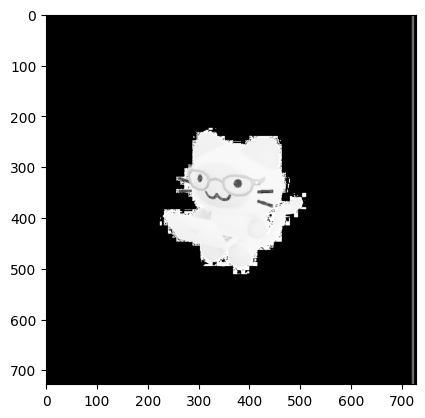

In [134]:
# ── 2. Log transformation ──────────────────────────

# s = c · log(1 + r) --> We need to find c.
# We want the maximum output value (s) to be 255 when the maximum input value (r) is 255:
# 255 = c · log(1 + 255)
# c = 255 / log(1 + 255)

import math
img2 = img.convert("L")
arr = np.array(img2)
c = 255 / math.log(1 + 255)
# Apply the log transformation to each pixel
log_arr = c*np.log(1+arr)
log_arr = np.clip(log_arr, 0, 255).astype(np.uint8)
log_img = Image.fromarray(log_arr)
log_img.save("task3_1_log.jpg")
plt.imshow(log_img, cmap = cm.Greys_r)
plt.show()

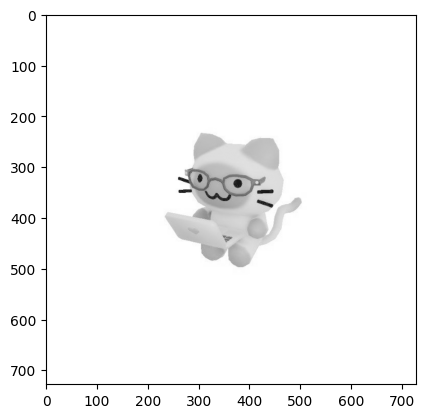

In [135]:

# ── 3. Power-law / Gamma correction ───────────────
img3= img.convert("L")
arr = np.array(img3)
arr = arr/255.0


gamma = 0.5
c = 1.0
gamma_arr = c * np.power(arr, gamma)
gamma_arr = np.clip(gamma_arr * 255, 0, 255).astype(np.uint8)

gamma_img = Image.fromarray(gamma_arr)
gamma_img.save("task3_2_gamma.jpg")

plt.imshow(gamma_img, cmap='gray', vmin=0, vmax=255)
plt.show()